#
FEATURE MATCHING (SIFT + KNN)


In [53]:
import numpy as np
import cv2

def get_correspondences(img1, img2):
    # Initialize SIFT detector
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # Use Brute Force Matcher with KNN (k=2)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # Apply ratio test to filter good correspondences
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Extract coordinates for the best 50 matches
    good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    return src_pts, dst_pts

In [54]:
def compute_homography(src_pts, dst_pts):

    A = []
    b = []
    for i in range(len(src_pts)):
        x, y = src_pts[i]
        xp, yp = dst_pts[i]
        # Linear equations derived from p' = Hp
        A.append([-x, -y, -1, 0, 0, 0, xp*x, xp*y])
        b.append(-xp)
        A.append([0, 0, 0, -x, -y, -1, yp*x, yp*y])
        b.append(-yp)

    # Solve for 8 unknowns (H33 is fixed at 1)
    x_vars = np.linalg.lstsq(np.array(A), np.array(b), rcond=None)[0]
    H = np.append(x_vars, 1.0).reshape(3, 3)
    return H



In [55]:
def inverse_warp(src_img, H, out_shape):

    dst_img = np.zeros(out_shape, dtype=src_img.dtype)
    H_inv = np.linalg.inv(H)
    h_src, w_src = src_img.shape[:2]

    for y_dst in range(out_shape[0]):
        for x_dst in range(out_shape[1]):
            # p = H_inv * p_prime
            res = H_inv @ np.array([x_dst, y_dst, 1.0])
            x_src, y_src = res[0]/res[2], res[1]/res[2]

            # Bilinear Interpolation
            x0 = int(np.floor(x_src))
            x1 = x0 + 1
            y0 = int(np.floor(y_src))
            y1 = y0 + 1

            if 0 <= x0 and x1 < w_src and 0 <= y0 and y1 < h_src:
                wa = (x1 - x_src) * (y1 - y_src)
                wb = (x1 - x_src) * (y_src - y0)
                wc = (x_src - x0) * (y1 - y_src)
                wd = (x_src - x0) * (y_src - y0)

                # Stack interpolation for all 3 color channels
                dst_img[y_dst, x_dst] = (wa * src_img[y0, x0] + wb * src_img[y1, x0] +
                                         wc * src_img[y0, x1] + wd * src_img[y1, x1])
    return dst_img

In [56]:
def forward_warp(src_img, H, out_shape):
    " implementation of forward mapping "
    dst_img = np.zeros(out_shape, dtype=src_img.dtype)
    h, w = src_img.shape[:2]
    for y in range(h):
        for x in range(w):
            res = H @ np.array([x, y, 1.0])
            xp, yp = int(round(res[0]/res[2])), int(round(res[1]/res[2]))
            if 0 <= xp < out_shape[1] and 0 <= yp < out_shape[0]:
                dst_img[yp, xp] = src_img[y, x]
    return dst_img

def inverse_warp(src_img, H, out_shape):
    "Inverse warp with bilinear interpolation to avoid holes "
    dst_img = np.zeros(out_shape, dtype=src_img.dtype)
    H_inv = np.linalg.inv(H)
    h_src, w_src = src_img.shape[:2]

    for y_dst in range(out_shape[0]):
        for x_dst in range(out_shape[1]):
            res = H_inv @ np.array([x_dst, y_dst, 1.0])
            x_src, y_src = res[0]/res[2], res[1]/res[2]

            x0, y0 = int(np.floor(x_src)), int(np.floor(y_src))
            x1, y1 = x0 + 1, y0 + 1

            if 0 <= x0 and x1 < w_src and 0 <= y0 and y1 < h_src:
                # Bilinear weights [cite: 96]
                wa, wb = (x1 - x_src) * (y1 - y_src), (x1 - x_src) * (y_src - y0)
                wc, wd = (x_src - x0) * (y1 - y_src), (x_src - x0) * (y_src - y0)
                dst_img[y_dst, x_dst] = (wa * src_img[y0, x0] + wb * src_img[y1, x0] +
                                         wc * src_img[y0, x1] + wd * src_img[y1, x1])
    return dst_img


In [57]:
def weighted_blend(warped_img, base_img):
    #  Create binary masks (1 where there is a pixel, 0 where it's black)
    mask1 = (np.sum(warped_img, axis=2) > 0).astype(np.float32)
    mask2 = (np.sum(base_img, axis=2) > 0).astype(np.float32)

    # Define your weights (w1 and w2)
    # Using distance transform makes the weights grow towards the center of each image
    w1 = cv2.distanceTransform(mask1.astype(np.uint8), cv2.DIST_L2, 3)
    w2 = cv2.distanceTransform(mask2.astype(np.uint8), cv2.DIST_L2, 3)

    # 3. Apply your equation: (w1*I1 + w2*I2) / (w1 + w2)
    # Add a tiny epsilon (1e-10) to the denominator to avoid dividing by zero
    denominator = w1 + w2
    denominator[denominator == 0] = 1 # Avoid division by zero in non-overlap areas

    # We need to reshape weights to (H, W, 1) to multiply with (H, W, 3) images
    w1_3d = w1[:, :, np.newaxis]
    w2_3d = w2[:, :, np.newaxis]
    den_3d = denominator[:, :, np.newaxis]

    # The actual equation logic
    result = (warped_img.astype(np.float32) * w1_3d + base_img.astype(np.float32) * w2_3d) / den_3d

    return result.astype(np.uint8)

In [58]:
def create_mosaic(img1, img2):
    # 1. Get correspondences and compute H
    src_pts, dst_pts = get_correspondences(img1, img2)
    H = compute_homography(src_pts, dst_pts)

    # 2. Get dimensions
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # 3. Calculate the corners of img1 after it is warped by H
    pts = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)

    # Manually project corners: p' = H * p
    warped_corners = []
    for p in pts:
        p_homo = np.array([p[0][0], p[0][1], 1.0])
        projected = H @ p_homo
        warped_corners.append([projected[0]/projected[2], projected[1]/projected[2]])

    warped_corners = np.array(warped_corners)

    # 4. Find the boundaries of the new canvas (including img2 at 0,0)
    all_coords = np.concatenate((warped_corners, [[0, 0], [0, h2], [w2, h2], [w2, 0]]), axis=0)

    min_x = int(np.floor(np.min(all_coords[:, 0])))
    min_y = int(np.floor(np.min(all_coords[:, 1])))
    max_x = int(np.ceil(np.max(all_coords[:, 0])))
    max_y = int(np.ceil(np.max(all_coords[:, 1])))

    # 5. Define Output Shape and Translation Matrix T
    output_shape = (max_y - min_y, max_x - min_x, 3)
    T = np.array([[1, 0, -min_x],
                  [0, 1, -min_y],
                  [0, 0, 1]])

    # 6. Prepare the two layers for blending
    # Layer 1: Warped img1 (shifted by T)
    warped_layer = inverse_warp(img1, T @ H, output_shape)

    # Layer 2: img2 (placed at its relative offset)
    base_layer = np.zeros(output_shape, dtype=np.uint8)
    y_offset, x_offset = -min_y, -min_x
    base_layer[y_offset:y_offset+h2, x_offset:x_offset+w2] = img2

    # 7. Final Weighted Blend
    final_result = weighted_blend(warped_layer, base_layer)

    return final_result

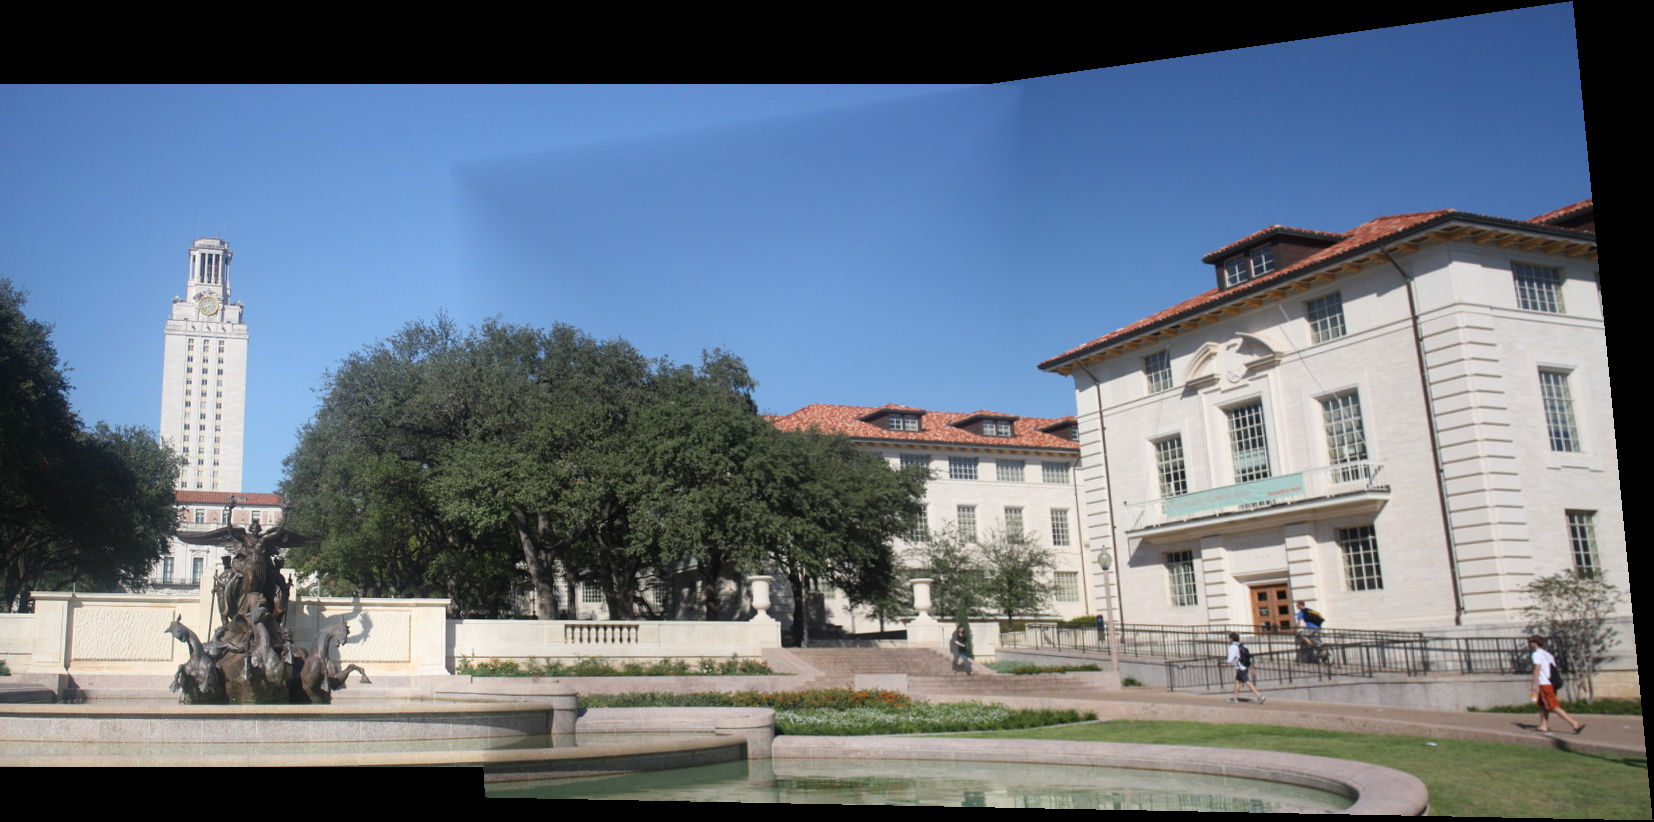

In [59]:
from google.colab.patches import cv2_imshow

if __name__ == "__main__":
    # Replace these with your actual filenames [cite: 77, 78]
    image_left = cv2.imread("/content/drive/MyDrive/CV/Assignemnt2/pano_image1.jpg")
    image_right = cv2.imread('/content/drive/MyDrive/CV/Assignemnt2/pano_image2.jpg')

    if image_left is not None and image_right is not None:
        result = create_mosaic(image_left, image_right)
        cv2_imshow(result)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Check image paths!")

BONUS


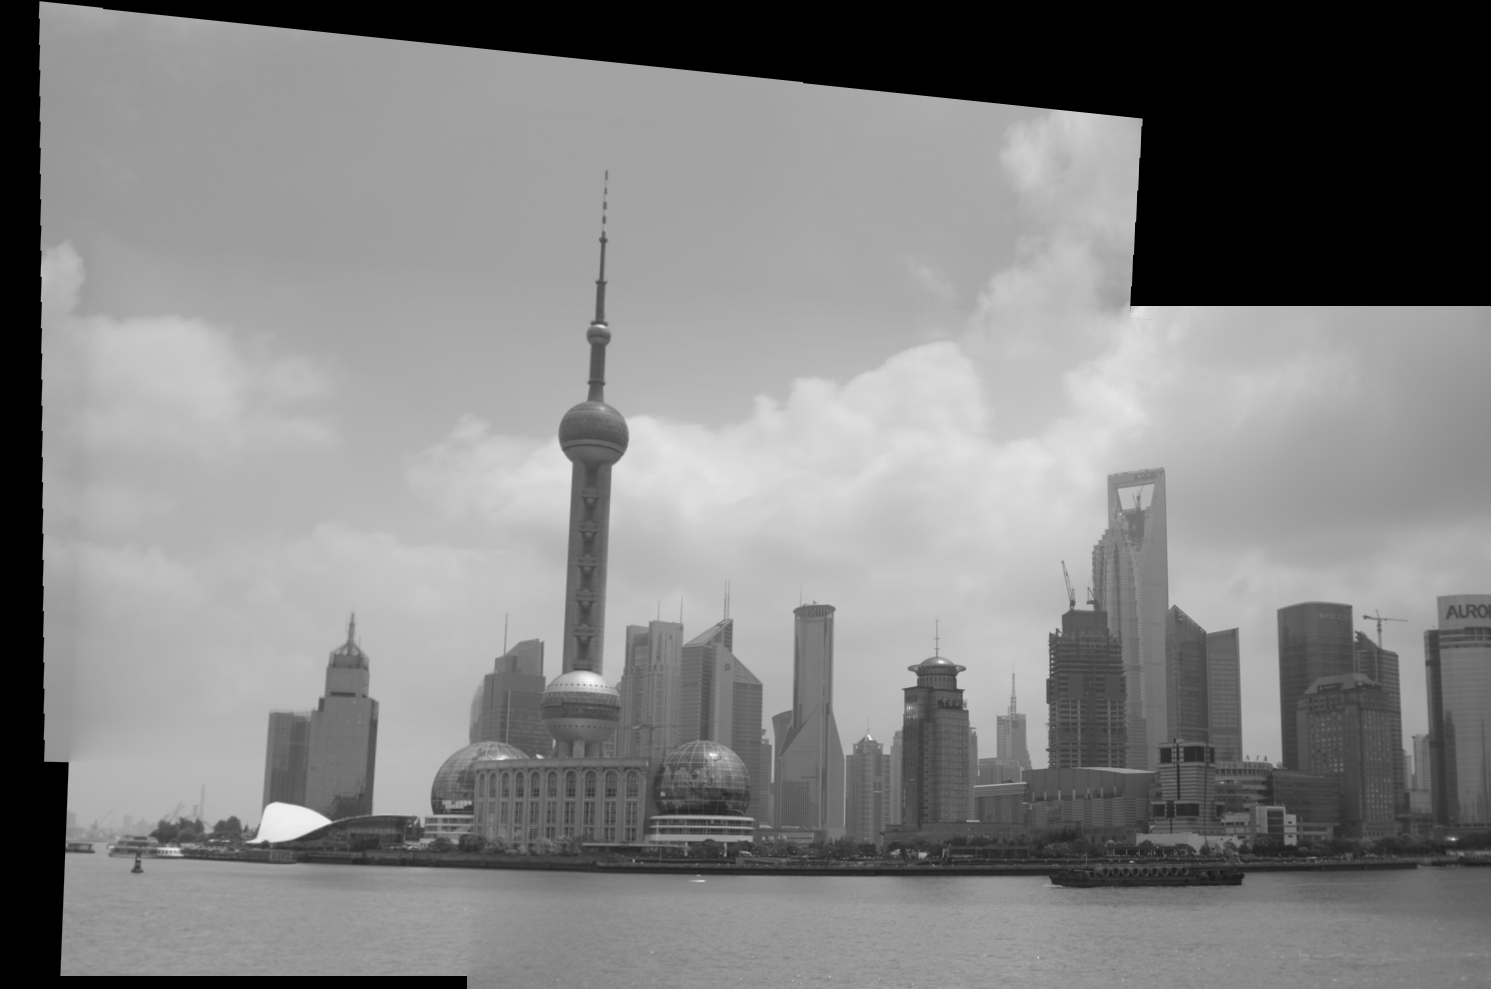

In [61]:
if __name__ == "__main__":
    img21 = cv2.imread('/content/drive/MyDrive/CV/Assignemnt2/shanghai-21.png')
    img22 = cv2.imread('/content/drive/MyDrive/CV/Assignemnt2/shanghai-22.png')
    img23 = cv2.imread('/content/drive/MyDrive/CV/Assignemnt2/shanghai-23.png')

    # Step 1: Stitch first two images
    # Result1 effectively becomes the new "plane" or coordinate system
    result_1_2 = create_mosaic(img22, img21)

    # Step 2 & 3: Stitch the result with the third image
    # Note: Finding correspondences in a large panorama can be slower
    final_panorama = create_mosaic(result_1_2, img23)
    cv2_imshow(final_panorama)
    cv2.waitKey(0)

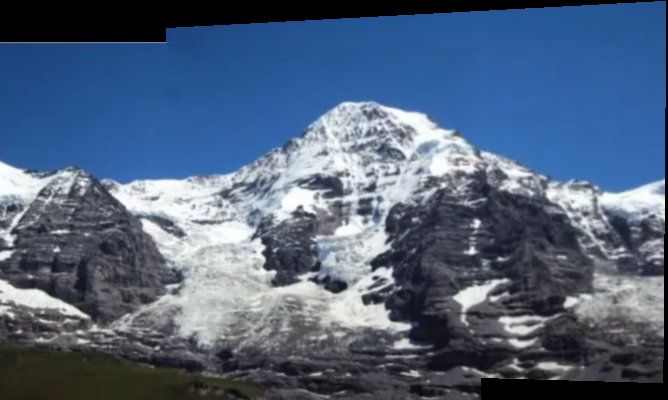

In [62]:
if __name__ == "__main__":
    # Replace these with your actual filenames [cite: 77, 78]
    image_left = cv2.imread("/content/drive/MyDrive/CV/Assignemnt2/Screenshot (158).png")
    image_right = cv2.imread('/content/drive/MyDrive/CV/Assignemnt2/right.png')

    if image_left is not None and image_right is not None:
        result = create_mosaic(image_left, image_right)
        cv2_imshow(result)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Check image paths!")